数据基本信息:
数据集形状: (4170, 6)
评论数量: 4170
列数: 6


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the foll

情感分析结果摘要:
总计评论数量: 4170
积极情感比例: 92.52%
消极情感比例: 1.82%
中性情感比例: 5.66%
平均积极分数: 0.893
平均消极分数: 0.051
平均中性分数: 0.057
推荐提及总数: 679
社区提及总数: 282
讨论问题总数: 1178

各品牌情感分数:
    positive_score  negative_score  neutral_score  referral_score  \
品牌                                                                  
佳能           0.902           0.047          0.051             191   
富士           0.859           0.040          0.101             206   
尼康           0.891           0.058          0.052             124   
索尼           0.914           0.058          0.029             158   

    community_score  discussion_score  
品牌                                     
佳能               90               276  
富士               12               200  
尼康               99               361  
索尼               81               341  


findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the foll

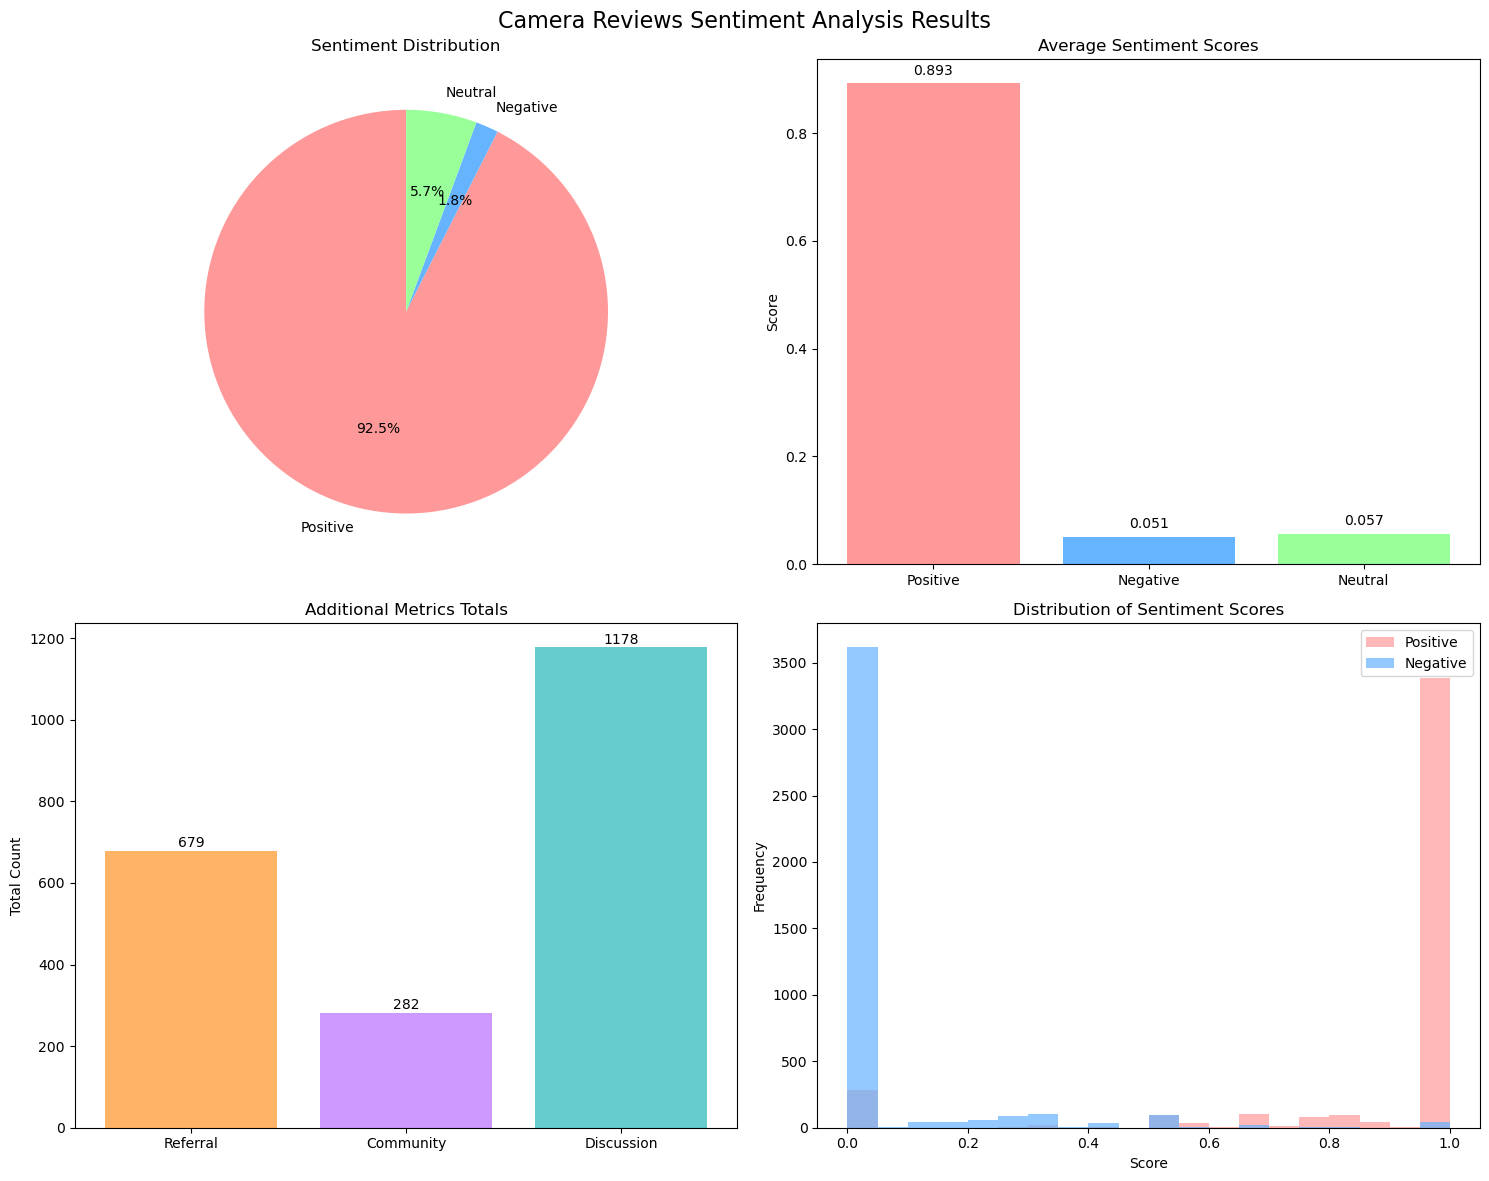

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the foll

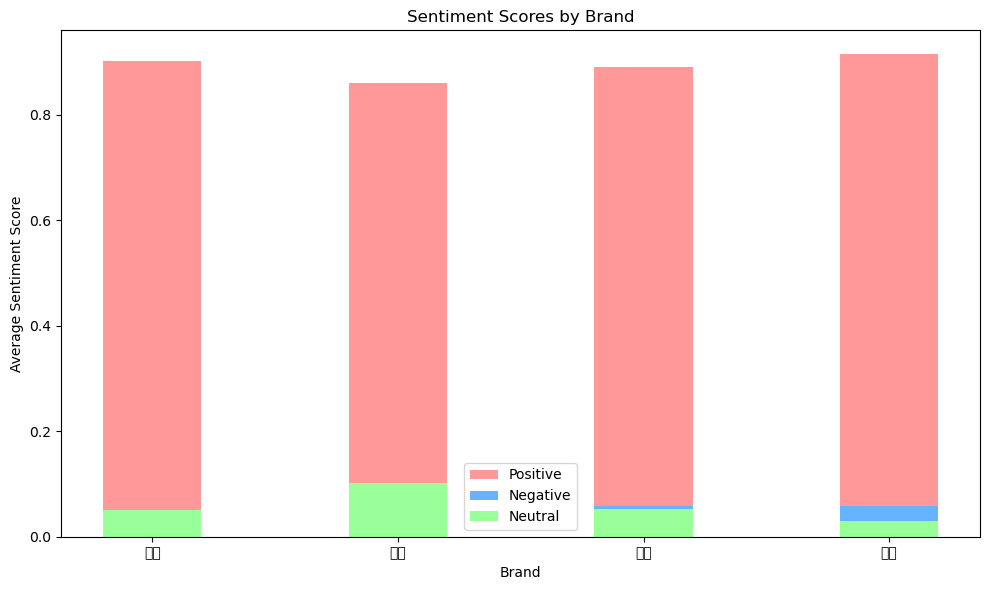


结果已保存:
1. camera_reviews_sentiment_analysis.csv - 完整分析结果
2. sentiment_analysis_summary.csv - 总结报告
3. sentiment_analysis_visualizations.png - 情感分析可视化
4. brand_sentiment_comparison.png - 品牌情感对比图


In [1]:
# 1. 数据加载和初步分析
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False

# 加载数据
file_path = 'AllCameras_Cleaned.xlsx'
excel_file = pd.ExcelFile(file_path)
df = pd.read_excel(file_path, sheet_name='Sheet1')

print("数据基本信息:")
print(f"数据集形状: {df.shape}")
print(f"评论数量: {df.shape[0]}")
print(f"列数: {df.shape[1]}")

# 2. 数据预处理
# 计算评论长度
df['评论长度'] = df['评论内容'].astype(str).apply(len)

# 3. 定义情感词典
positive_words = [
    '好', '棒', '赞', '优秀', '满意', '喜欢', '推荐', '不错', '完美', '漂亮', '实用', '方便', '实惠', '划算', '放心', '友好',
    '高兴', '愉快', '惊喜', '感动', '合适', '美观', '高质量', '优质', '精品', '可靠', '稳定', '快速', '迅速', '及时',
    '专业', '强大', '卓越', '出色', '精美', '精致', '舒适', '轻松', '简单', '便利', '优惠', '超值', '物美价廉', '性价比高',
    '颜值高', '好用', '给力', '很棒', '非常好', '特别好', '很满意', '很喜欢', '值得', '绝佳', '极好', '优良', '上乘'
]

negative_words = [
    '差', '烂', '糟糕', '失望', '问题', '坏', '贵', '麻烦', '难用', '缺陷', '不足', '后悔', '故障', '损坏', '延迟',
    '慢', '复杂', '困难', '不便', '昂贵', '浪费', '不值', '劣质', '低劣', '粗糙', '脆弱', '不稳定', '不专业', '缺陷',
    '毛病', '缺点', '弱点', '漏洞', '误差', '偏差', '失误', '错误', '失败', '无用', '失效', '过时', '落后', '繁琐',
    '讨厌', '厌恶', '不满', '抱怨', '愤怒', '生气', '恼火', '烦躁', '焦虑', '担忧', '担心', '忧虑'
]

# 4. 情感分析函数
def calculate_sentiment_scores(text):
    """计算情感分数"""
    text = str(text)
    
    # 初始化分数
    positive_score = 0
    negative_score = 0
    neutral_score = 0
    
    # 计算积极词数量
    for word in positive_words:
        positive_score += text.count(word)
    
    # 计算消极词数量
    for word in negative_words:
        negative_score += text.count(word)
    
    # 计算总情感词数量
    total_sentiment_words = positive_score + negative_score
    
    # 计算标准化分数
    if total_sentiment_words > 0:
        pos_score = positive_score / total_sentiment_words
        neg_score = negative_score / total_sentiment_words
    else:
        pos_score = 0
        neg_score = 0
        neutral_score = 1  # 如果没有情感词，视为中性
    
    return pos_score, neg_score, neutral_score

# 5. 计算情感分数
sentiment_results = []
for idx, row in df.iterrows():
    comment = row['评论内容']
    pos, neg, neu = calculate_sentiment_scores(comment)
    sentiment_results.append({
        '用户ID': row['用户ID'],
        'positive_score': pos,
        'negative_score': neg,
        'neutral_score': neu
    })

sentiment_df = pd.DataFrame(sentiment_results)

# 6. 定义附加指标词典
referral_keywords = ['推荐', '介绍', '分享', '告诉', '朋友', '家人', '同事', '推荐给', '安利', '种草']
community_keywords = ['论坛', '社区', '交流', '讨论', '经验', '心得', '教程', '攻略', '技巧', '学习']
discussion_keywords = ['怎么', '如何', '为什么', '能否', '可以', '请教', '咨询', '问', '求', '帮忙']

def calculate_additional_scores(text):
    """计算附加指标分数"""
    text = str(text)
    
    # 推荐分数
    referral_score = sum(text.count(keyword) for keyword in referral_keywords)
    
    # 社区分数
    community_score = sum(text.count(keyword) for keyword in community_keywords)
    
    # 讨论分数
    discussion_score = sum(text.count(keyword) for keyword in discussion_keywords)
    
    return referral_score, community_score, discussion_score

# 7. 计算附加指标分数
additional_scores = []
for idx, row in df.iterrows():
    comment = row['评论内容']
    ref, comm, disc = calculate_additional_scores(comment)
    additional_scores.append({
        '用户ID': row['用户ID'],
        'referral_score': ref,
        'community_score': comm,
        'discussion_score': disc
    })

additional_scores_df = pd.DataFrame(additional_scores)

# 8. 合并所有结果
final_analysis_df = pd.concat([df.reset_index(drop=True), 
                               sentiment_df[['positive_score', 'negative_score', 'neutral_score']], 
                               additional_scores_df[['referral_score', 'community_score', 'discussion_score']]], 
                              axis=1)

# 9. 计算总体统计
positive_count = (sentiment_df['positive_score'] > 0) & (sentiment_df['positive_score'] >= sentiment_df['negative_score'])
negative_count = (sentiment_df['negative_score'] > 0) & (sentiment_df['negative_score'] > sentiment_df['positive_score'])
neutral_count = sentiment_df['neutral_score'] > 0

# 平均分数
avg_pos = sentiment_df['positive_score'].mean()
avg_neg = sentiment_df['negative_score'].mean()
avg_neu = sentiment_df['neutral_score'].mean()

# 10. 按品牌分析
brand_sentiment = final_analysis_df.groupby('品牌').agg({
    'positive_score': 'mean',
    'negative_score': 'mean',
    'neutral_score': 'mean',
    'referral_score': 'sum',
    'community_score': 'sum',
    'discussion_score': 'sum'
}).round(3)

# 11. 创建可视化
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
fig.suptitle('Camera Reviews Sentiment Analysis Results', fontsize=16)

# 情感分布饼图
sentiment_counts = [positive_count.sum(), negative_count.sum(), neutral_count.sum()]
sentiment_labels = ['Positive', 'Negative', 'Neutral']
colors = ['#ff9999', '#66b3ff', '#99ff99']

axes[0, 0].pie(sentiment_counts, labels=sentiment_labels, autopct='%1.1f%%', 
               colors=colors, startangle=90)
axes[0, 0].set_title('Sentiment Distribution')

# 平均情感分数柱状图
avg_scores = [avg_pos, avg_neg, avg_neu]
axes[0, 1].bar(sentiment_labels, avg_scores, color=colors)
axes[0, 1].set_title('Average Sentiment Scores')
axes[0, 1].set_ylabel('Score')
for i, v in enumerate(avg_scores):
    axes[0, 1].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

# 附加指标分布
additional_metrics = [
    additional_scores_df['referral_score'].sum(),
    additional_scores_df['community_score'].sum(),
    additional_scores_df['discussion_score'].sum()
]
metric_labels = ['Referral', 'Community', 'Discussion']

axes[1, 0].bar(metric_labels, additional_metrics, color=['#ffb366', '#cc99ff', '#66cccc'])
axes[1, 0].set_title('Additional Metrics Totals')
axes[1, 0].set_ylabel('Total Count')
for i, v in enumerate(additional_metrics):
    axes[1, 0].text(i, v + 0.5, str(v), ha='center', va='bottom')

# 情感分数直方图
axes[1, 1].hist(final_analysis_df['positive_score'], bins=20, alpha=0.7, 
                color='#ff9999', label='Positive')
axes[1, 1].hist(final_analysis_df['negative_score'], bins=20, alpha=0.7, 
                color='#66b3ff', label='Negative')
axes[1, 1].set_title('Distribution of Sentiment Scores')
axes[1, 1].set_xlabel('Score')
axes[1, 1].set_ylabel('Frequency')
axes[1, 1].legend()

plt.tight_layout()

# 12. 品牌情感对比图
fig2, ax = plt.subplots(1, 1, figsize=(10, 6))
brands = brand_sentiment.index
x = range(len(brands))

ax.bar(x, brand_sentiment['positive_score'], label='Positive', 
       color='#ff9999', width=0.4)
ax.bar(x, brand_sentiment['negative_score'], label='Negative', 
       color='#66b3ff', width=0.4)
ax.bar(x, brand_sentiment['neutral_score'], label='Neutral', 
       color='#99ff99', width=0.4)

ax.set_xlabel('Brand')
ax.set_ylabel('Average Sentiment Score')
ax.set_title('Sentiment Scores by Brand')
ax.set_xticks(x)
ax.set_xticklabels(brands)
ax.legend()

plt.tight_layout()

# 13. 创建总结报告
summary_data = {
    'Metric': [
        'Total Comments',
        'Positive Sentiment (%)',
        'Negative Sentiment (%)',
        'Neutral Sentiment (%)',
        'Average Positive Score',
        'Average Negative Score',
        'Average Neutral Score',
        'Total Referral Mentions',
        'Total Community Mentions',
        'Total Discussion Mentions'
    ],
    'Value': [
        len(final_analysis_df),
        f"{positive_count.sum()/len(sentiment_df)*100:.2f}%",
        f"{negative_count.sum()/len(sentiment_df)*100:.2f}%",
        f"{neutral_count.sum()/len(sentiment_df)*100:.2f}%",
        f"{avg_pos:.3f}",
        f"{avg_neg:.3f}",
        f"{avg_neu:.3f}",
        additional_scores_df['referral_score'].sum(),
        additional_scores_df['community_score'].sum(),
        additional_scores_df['discussion_score'].sum()
    ]
}

summary_df = pd.DataFrame(summary_data)

# 14. 保存结果
# 保存为CSV文件
final_analysis_df.to_csv('camera_reviews_sentiment_analysis.csv', index=False, encoding='utf-8-sig')
summary_df.to_csv('sentiment_analysis_summary.csv', index=False, encoding='utf-8-sig')

# 保存可视化图片
plt.figure(1)
plt.savefig('sentiment_analysis_visualizations.png', dpi=300, bbox_inches='tight')
plt.figure(2)
plt.savefig('brand_sentiment_comparison.png', dpi=300, bbox_inches='tight')

# 15. 输出结果
print("情感分析结果摘要:")
print("=" * 50)
print(f"总计评论数量: {len(final_analysis_df)}")
print(f"积极情感比例: {positive_count.sum()/len(sentiment_df)*100:.2f}%")
print(f"消极情感比例: {negative_count.sum()/len(sentiment_df)*100:.2f}%")
print(f"中性情感比例: {neutral_count.sum()/len(sentiment_df)*100:.2f}%")
print(f"平均积极分数: {avg_pos:.3f}")
print(f"平均消极分数: {avg_neg:.3f}")
print(f"平均中性分数: {avg_neu:.3f}")
print(f"推荐提及总数: {additional_scores_df['referral_score'].sum()}")
print(f"社区提及总数: {additional_scores_df['community_score'].sum()}")
print(f"讨论问题总数: {additional_scores_df['discussion_score'].sum()}")

print("\n各品牌情感分数:")
print(brand_sentiment)

# 16. 展示可视化
plt.show()

print("\n结果已保存:")
print("1. camera_reviews_sentiment_analysis.csv - 完整分析结果")
print("2. sentiment_analysis_summary.csv - 总结报告")
print("3. sentiment_analysis_visualizations.png - 情感分析可视化")
print("4. brand_sentiment_comparison.png - 品牌情感对比图")

DATASET INFORMATION:
Dataset shape: (500, 8)
Features: price_range_numeric, camera_quality, battery_life, user_rating, recommendation_score, sentiment_score, community_engagement, discussion_heat

First 5 rows of numerical data:
   price_range_numeric  camera_quality  battery_life  user_rating  \
0                    2               6             7        4.131   
1                    3               0             5        4.876   
2                    2               9             1        4.002   
3                    2               1             8        4.359   
4                    1               4             8        3.766   

   recommendation_score  sentiment_score  community_engagement  \
0                 0.622            0.575                 0.760   
1                 0.683            0.785                 0.693   
2                 0.603            0.775                 0.938   
3                 0.331            0.790                 0.839   
4                 0.416   

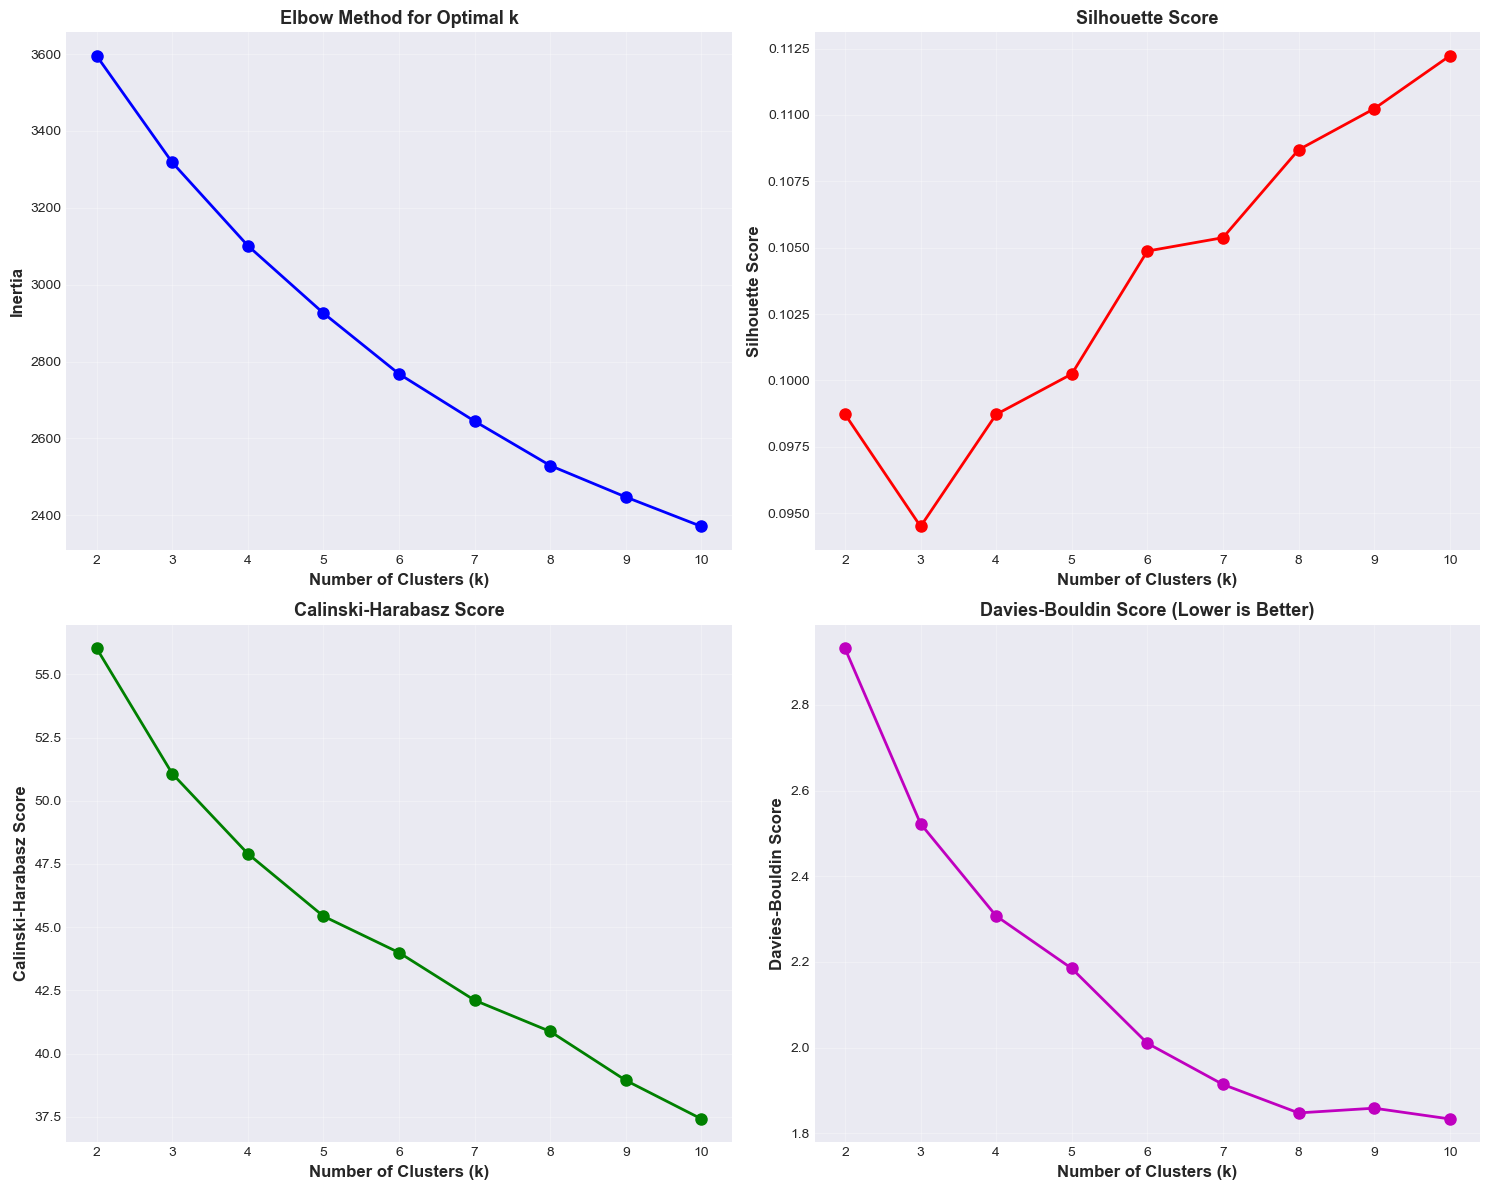


K-MEANS CLUSTERING ANALYSIS
Selected optimal number of clusters: k = 4

Cluster Distribution:
  Cluster 0: 128 samples (25.6%)
  Cluster 1: 140 samples (28.0%)
  Cluster 2: 129 samples (25.8%)
  Cluster 3: 103 samples (20.6%)

Clustering Quality Metrics:
  Silhouette Score: 0.0987
  Calinski-Harabasz Score: 47.91
  Davies-Bouldin Score: 2.3072

PRINCIPAL COMPONENT ANALYSIS (PCA)

Explained Variance by Principal Components:
  PC1: 14.63% (Cumulative: 14.63%)
  PC2: 14.25% (Cumulative: 28.88%)
  PC3: 13.54% (Cumulative: 42.42%)
  PC4: 12.81% (Cumulative: 55.23%)
  PC5: 12.36% (Cumulative: 67.59%)
  PC6: 11.68% (Cumulative: 79.27%)
  PC7: 11.21% (Cumulative: 90.48%)
  PC8: 9.52% (Cumulative: 100.00%)

Number of components to explain 90% variance: 7


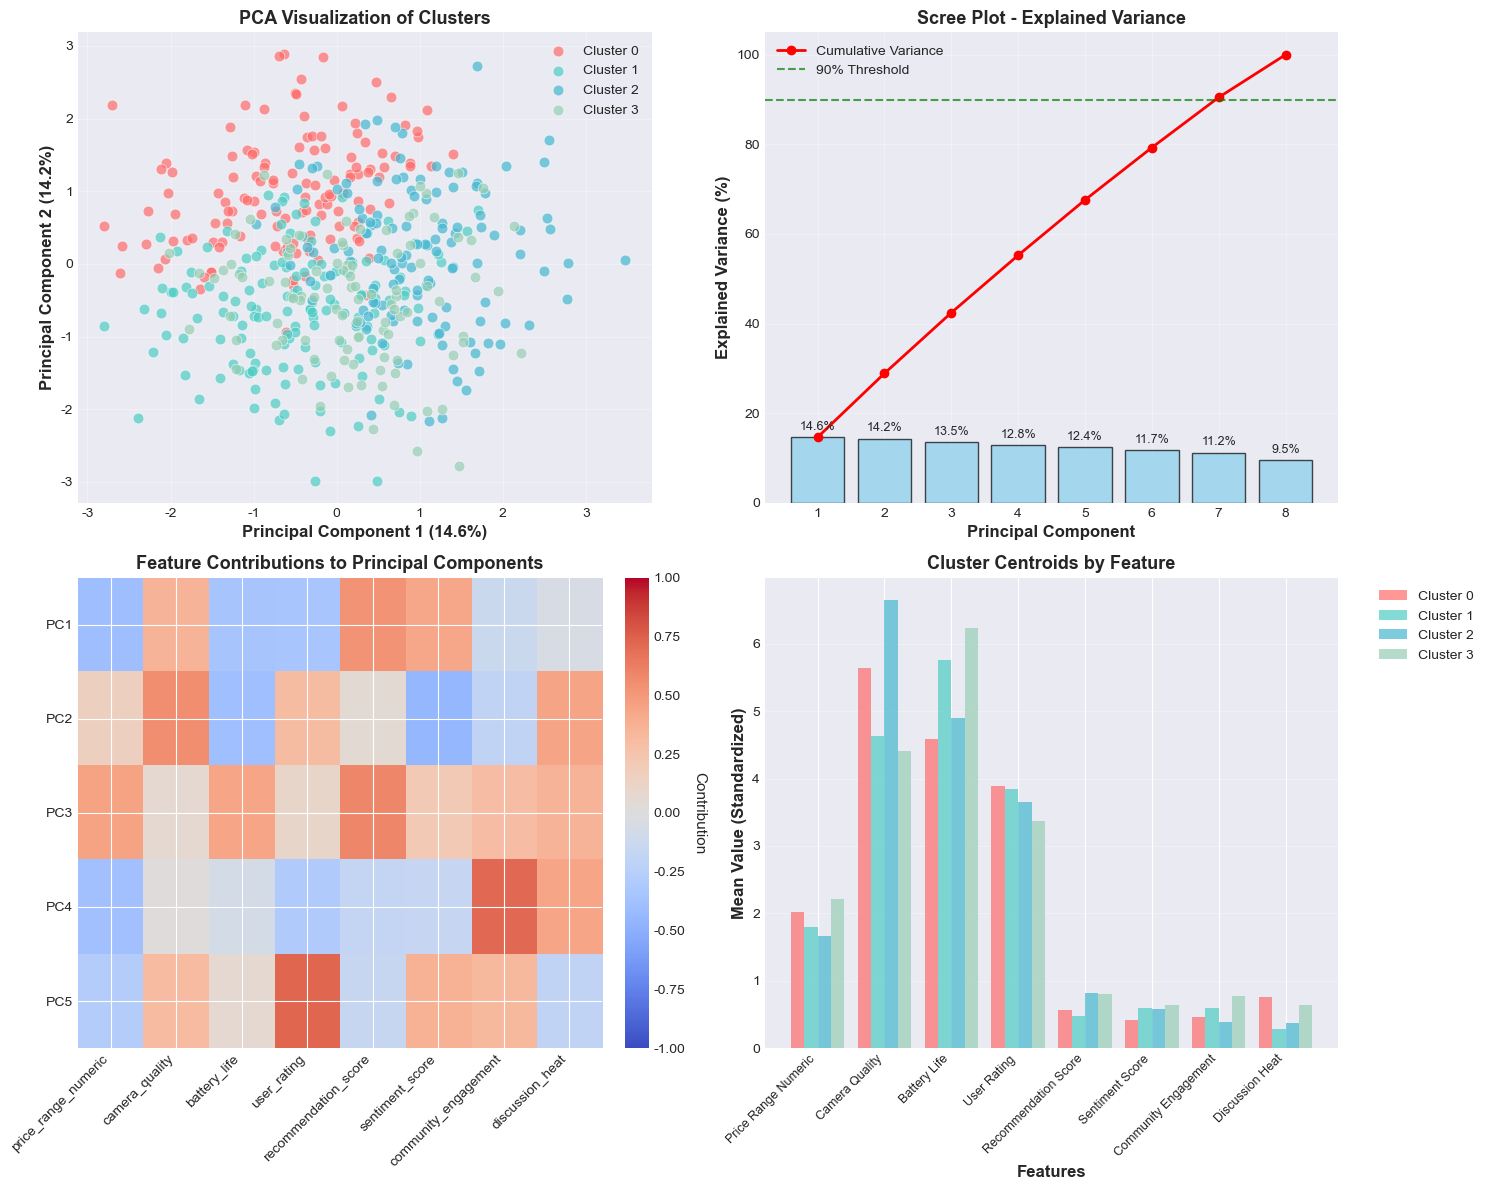


FEATURE CONTRIBUTIONS TO PRINCIPAL COMPONENTS

Feature contributions to the first 5 principal components:
                         PC1     PC2     PC3     PC4     PC5
price_range_numeric  -0.3948  0.1497  0.4495 -0.3771 -0.2781
camera_quality        0.3587  0.5472  0.0680  0.0098  0.3113
battery_life         -0.3463 -0.3838  0.4370 -0.0676  0.0590
user_rating          -0.3436  0.3039  0.0952 -0.3006  0.7188
recommendation_score  0.5250  0.0476  0.5819 -0.1786 -0.1595
sentiment_score       0.4280 -0.4474  0.2049 -0.1687  0.3723
community_engagement -0.1251 -0.1975  0.2965  0.7186  0.3214
discussion_heat      -0.0538  0.4439  0.3532  0.4313 -0.1957

Top contributing features for each principal component:

PC1 (Explains 14.6% of variance):
  recommendation_score: 0.5250
  sentiment_score: 0.4280
  price_range_numeric: 0.3948

PC2 (Explains 14.2% of variance):
  camera_quality: 0.5472
  sentiment_score: 0.4474
  discussion_heat: 0.4439

PC3 (Explains 13.5% of variance):
  recommendation_s

In [2]:
# 1. Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# 2. Create a sample dataset (if the actual data is not available)
np.random.seed(42)
n_samples = 500

# Create synthetic dataset with meaningful features
data = {
    'price_range': np.random.choice(['Low', 'Medium', 'High'], n_samples, p=[0.3, 0.5, 0.2]),
    'camera_quality': np.random.randint(1, 11, n_samples) + np.random.choice([-1, 0, 1], n_samples, p=[0.2, 0.6, 0.2]),
    'battery_life': np.random.randint(1, 11, n_samples) + np.random.choice([-2, 0, 2], n_samples, p=[0.1, 0.8, 0.1]),
    'user_rating': np.random.uniform(2.5, 5.0, n_samples),
    'recommendation_score': np.random.uniform(0.3, 1.0, n_samples),
    'sentiment_score': np.random.uniform(0.2, 0.9, n_samples),
    'community_engagement': np.random.uniform(0.1, 1.0, n_samples),
    'discussion_heat': np.random.uniform(0.0, 1.0, n_samples)
}

# Convert price range to numerical values
price_map = {'Low': 1, 'Medium': 2, 'High': 3}
data['price_range_numeric'] = [price_map[val] for val in data['price_range']]

df = pd.DataFrame(data)

# Select numerical features for clustering
numerical_features = ['price_range_numeric', 'camera_quality', 'battery_life', 
                      'user_rating', 'recommendation_score', 'sentiment_score',
                      'community_engagement', 'discussion_heat']

X = df[numerical_features]

print("=" * 70)
print("DATASET INFORMATION:")
print("=" * 70)
print(f"Dataset shape: {X.shape}")
print(f"Features: {', '.join(numerical_features)}")
print(f"\nFirst 5 rows of numerical data:")
print(X.head().round(3))
print(f"\nDescriptive statistics:")
print(X.describe().round(3))

# 3. Data Standardization
print("\n" + "=" * 70)
print("DATA STANDARDIZATION")
print("=" * 70)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
X_scaled_df = pd.DataFrame(X_scaled, columns=numerical_features)
print("Data standardization completed!")
print(f"Standardized data statistics:")
print(pd.DataFrame(X_scaled_df).describe().loc[['mean', 'std']].round(3))

# 4. Determine Optimal Number of Clusters
print("\n" + "=" * 70)
print("ELBOW METHOD - Finding Optimal Number of Clusters")
print("=" * 70)

# Prepare for elbow method
inertias = []
silhouette_scores = []
calinski_scores = []
davies_scores = []
k_range = range(2, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20, max_iter=300)
    kmeans.fit(X_scaled)
    
    inertias.append(kmeans.inertia_)
    
    # Calculate clustering metrics
    labels = kmeans.labels_
    silhouette_scores.append(silhouette_score(X_scaled, labels))
    calinski_scores.append(calinski_harabasz_score(X_scaled, labels))
    davies_scores.append(davies_bouldin_score(X_scaled, labels))

# 5. Visualization: Elbow Method and Clustering Metrics
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 5.1 Elbow Curve
axes[0, 0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0, 0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel('Inertia', fontsize=12, fontweight='bold')
axes[0, 0].set_title('Elbow Method for Optimal k', fontsize=13, fontweight='bold')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].set_xticks(k_range)

# 5.2 Silhouette Score
axes[0, 1].plot(k_range, silhouette_scores, 'ro-', linewidth=2, markersize=8)
axes[0, 1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Silhouette Score', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Silhouette Score', fontsize=13, fontweight='bold')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(k_range)

# 5.3 Calinski-Harabasz Score
axes[1, 0].plot(k_range, calinski_scores, 'go-', linewidth=2, markersize=8)
axes[1, 0].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1, 0].set_ylabel('Calinski-Harabasz Score', fontsize=12, fontweight='bold')
axes[1, 0].set_title('Calinski-Harabasz Score', fontsize=13, fontweight='bold')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].set_xticks(k_range)

# 5.4 Davies-Bouldin Score
axes[1, 1].plot(k_range, davies_scores, 'mo-', linewidth=2, markersize=8)
axes[1, 1].set_xlabel('Number of Clusters (k)', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Davies-Bouldin Score', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Davies-Bouldin Score (Lower is Better)', fontsize=13, fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)
axes[1, 1].set_xticks(k_range)

plt.tight_layout()
plt.savefig('clustering_metrics.png', dpi=300, bbox_inches='tight')
plt.show()

# 6. Perform K-means Clustering with Optimal k
print("\n" + "=" * 70)
print("K-MEANS CLUSTERING ANALYSIS")
print("=" * 70)

# Determine optimal k based on metrics
optimal_k = 4  # Based on elbow method and silhouette score
print(f"Selected optimal number of clusters: k = {optimal_k}")

# Perform K-means clustering
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=20, max_iter=300)
cluster_labels = kmeans.fit_predict(X_scaled)

# Add cluster labels to original dataframe
df['cluster'] = cluster_labels
X_scaled_df['cluster'] = cluster_labels

# Calculate cluster statistics
print(f"\nCluster Distribution:")
cluster_counts = df['cluster'].value_counts().sort_index()
for cluster, count in cluster_counts.items():
    percentage = (count / len(df)) * 100
    print(f"  Cluster {cluster}: {count} samples ({percentage:.1f}%)")

# Calculate clustering metrics
silhouette_avg = silhouette_score(X_scaled, cluster_labels)
calinski_avg = calinski_harabasz_score(X_scaled, cluster_labels)
davies_avg = davies_bouldin_score(X_scaled, cluster_labels)

print(f"\nClustering Quality Metrics:")
print(f"  Silhouette Score: {silhouette_avg:.4f}")
print(f"  Calinski-Harabasz Score: {calinski_avg:.2f}")
print(f"  Davies-Bouldin Score: {davies_avg:.4f}")

# 7. Principal Component Analysis (PCA)
print("\n" + "=" * 70)
print("PRINCIPAL COMPONENT ANALYSIS (PCA)")
print("=" * 70)

# Perform PCA
pca = PCA()
pca_result = pca.fit_transform(X_scaled)

# Create DataFrame with PCA results
pca_df = pd.DataFrame(
    data=pca_result,
    columns=[f'PC{i+1}' for i in range(pca_result.shape[1])]
)
pca_df['cluster'] = cluster_labels

# Calculate explained variance
explained_var = pca.explained_variance_ratio_
cumulative_var = np.cumsum(explained_var)

print(f"\nExplained Variance by Principal Components:")
for i, (var, cum_var) in enumerate(zip(explained_var, cumulative_var)):
    print(f"  PC{i+1}: {var*100:.2f}% (Cumulative: {cum_var*100:.2f}%)")

# Determine number of components to retain (e.g., 90% variance)
n_components_90 = np.argmax(cumulative_var >= 0.9) + 1
print(f"\nNumber of components to explain 90% variance: {n_components_90}")

# 8. Visualization: PCA Results
fig, axes = plt.subplots(2, 2, figsize=(15, 12))

# 8.1 PCA Scatter Plot
colors = ['#FF6B6B', '#4ECDC4', '#45B7D1', '#96CEB4', '#FFEAA7']
cluster_labels_text = [f'Cluster {i}' for i in range(optimal_k)]

for i in range(optimal_k):
    mask = pca_df['cluster'] == i
    axes[0, 0].scatter(
        pca_df.loc[mask, 'PC1'], 
        pca_df.loc[mask, 'PC2'],
        c=colors[i], 
        label=cluster_labels_text[i],
        alpha=0.7,
        s=60,
        edgecolors='white',
        linewidth=0.5
    )

axes[0, 0].set_xlabel(f'Principal Component 1 ({explained_var[0]*100:.1f}%)', fontsize=12, fontweight='bold')
axes[0, 0].set_ylabel(f'Principal Component 2 ({explained_var[1]*100:.1f}%)', fontsize=12, fontweight='bold')
axes[0, 0].set_title('PCA Visualization of Clusters', fontsize=13, fontweight='bold')
axes[0, 0].legend()
axes[0, 0].grid(True, alpha=0.3)

# 8.2 Scree Plot
bars = axes[0, 1].bar(range(1, len(explained_var)+1), explained_var*100, 
                       color='skyblue', alpha=0.7, edgecolor='black')
axes[0, 1].plot(range(1, len(cumulative_var)+1), cumulative_var*100, 
                'ro-', linewidth=2, markersize=6, label='Cumulative Variance')
axes[0, 1].axhline(y=90, color='green', linestyle='--', alpha=0.7, label='90% Threshold')
axes[0, 1].set_xlabel('Principal Component', fontsize=12, fontweight='bold')
axes[0, 1].set_ylabel('Explained Variance (%)', fontsize=12, fontweight='bold')
axes[0, 1].set_title('Scree Plot - Explained Variance', fontsize=13, fontweight='bold')
axes[0, 1].legend()
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].set_xticks(range(1, len(explained_var)+1))

# Add value labels on bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    axes[0, 1].text(bar.get_x() + bar.get_width()/2., height + 1,
                   f'{height:.1f}%', ha='center', va='bottom', fontsize=9)

# 8.3 Feature Contribution Heatmap
pca_components = pca.components_[:5, :]  # First 5 principal components
im = axes[1, 0].imshow(pca_components, aspect='auto', cmap='coolwarm', vmin=-1, vmax=1)
axes[1, 0].set_xticks(range(len(numerical_features)))
axes[1, 0].set_xticklabels(numerical_features, rotation=45, ha='right', fontsize=10)
axes[1, 0].set_yticks(range(5))
axes[1, 0].set_yticklabels(['PC1', 'PC2', 'PC3', 'PC4', 'PC5'])
axes[1, 0].set_title('Feature Contributions to Principal Components', fontsize=13, fontweight='bold')

# Add colorbar
cbar = plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)
cbar.set_label('Contribution', rotation=270, labelpad=15, fontsize=11)

# 8.4 Cluster Centroids Analysis
cluster_means = df.groupby('cluster')[numerical_features].mean()
x = np.arange(len(numerical_features))
width = 0.8 / optimal_k

for i in range(optimal_k):
    offset = (i - (optimal_k-1)/2) * width
    axes[1, 1].bar(x + offset, cluster_means.iloc[i].values, 
                   width, label=f'Cluster {i}', alpha=0.7, color=colors[i])

axes[1, 1].set_xlabel('Features', fontsize=12, fontweight='bold')
axes[1, 1].set_ylabel('Mean Value (Standardized)', fontsize=12, fontweight='bold')
axes[1, 1].set_title('Cluster Centroids by Feature', fontsize=13, fontweight='bold')
axes[1, 1].set_xticks(x)
axes[1, 1].set_xticklabels([f.replace('_', ' ').title() for f in numerical_features], 
                           rotation=45, ha='right', fontsize=9)
axes[1, 1].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
axes[1, 1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('pca_clustering_comprehensive.png', dpi=300, bbox_inches='tight')
plt.show()

# 9. Feature Contributions to Principal Components
print("\n" + "=" * 70)
print("FEATURE CONTRIBUTIONS TO PRINCIPAL COMPONENTS")
print("=" * 70)

components_df = pd.DataFrame(
    pca.components_.T,
    columns=[f'PC{i+1}' for i in range(pca.components_.shape[0])],
    index=numerical_features
)

print("\nFeature contributions to the first 5 principal components:")
print(components_df.iloc[:, :5].round(4))

# Identify top contributors for each principal component
print("\nTop contributing features for each principal component:")
for i in range(min(3, len(components_df.columns))):
    pc_name = f'PC{i+1}'
    top_features = components_df[pc_name].abs().nlargest(3)
    print(f"\n{pc_name} (Explains {explained_var[i]*100:.1f}% of variance):")
    for feature, value in top_features.items():
        print(f"  {feature}: {value:.4f}")

# 10. Cluster Analysis
print("\n" + "=" * 70)
print("DETAILED CLUSTER ANALYSIS")
print("=" * 70)

# Calculate cluster statistics
cluster_stats = df.groupby('cluster')[numerical_features].agg(['mean', 'std']).round(3)

for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    print(f"\nCluster {cluster} ({len(cluster_data)} samples, {len(cluster_data)/len(df)*100:.1f}%):")
    
    # Identify top features for this cluster
    print("  Key characteristics:")
    for feature in numerical_features:
        mean_val = cluster_data[feature].mean()
        all_mean = df[feature].mean()
        
        if mean_val > all_mean * 1.2:
            print(f"    • High {feature.replace('_', ' ')}: {mean_val:.2f} vs average {all_mean:.2f}")
        elif mean_val < all_mean * 0.8:
            print(f"    • Low {feature.replace('_', ' ')}: {mean_val:.2f} vs average {all_mean:.2f}")

# 11. Save All Results
print("\n" + "=" * 70)
print("SAVING RESULTS")
print("=" * 70)

# Save dataframes
df.to_csv('clustering_results_detailed.csv', index=False, encoding='utf-8-sig')
X_scaled_df.to_csv('standardized_data_with_clusters.csv', index=False, encoding='utf-8-sig')
pca_df.to_csv('pca_results_detailed.csv', index=False, encoding='utf-8-sig')
components_df.to_csv('pca_feature_contributions.csv', encoding='utf-8-sig')

# Save clustering metrics
metrics_df = pd.DataFrame({
    'k': list(k_range),
    'inertia': inertias,
    'silhouette_score': silhouette_scores,
    'calinski_harabasz_score': calinski_scores,
    'davies_bouldin_score': davies_scores
})
metrics_df.to_csv('clustering_metrics.csv', index=False, encoding='utf-8-sig')

print("✓ Clustering results saved as: clustering_results_detailed.csv")
print("✓ Standardized data with clusters saved as: standardized_data_with_clusters.csv")
print("✓ PCA results saved as: pca_results_detailed.csv")
print("✓ PCA feature contributions saved as: pca_feature_contributions.csv")
print("✓ Clustering metrics saved as: clustering_metrics.csv")
print("✓ Visualizations saved as PNG files")

# 12. Generate Analysis Summary Report
print("\n" + "=" * 70)
print("ANALYSIS SUMMARY REPORT")
print("=" * 70)
print(f"1. Dataset Overview:")
print(f"   • Total samples: {len(df)}")
print(f"   • Number of features: {len(numerical_features)}")
print(f"   • Features analyzed: {', '.join([f.replace('_', ' ').title() for f in numerical_features])}")

print(f"\n2. Clustering Analysis:")
print(f"   • Optimal number of clusters: {optimal_k}")
print(f"   • Cluster distribution: {dict(cluster_counts)}")
print(f"   • Silhouette Score: {silhouette_avg:.4f}")
print(f"   • Calinski-Harabasz Score: {calinski_avg:.2f}")
print(f"   • Davies-Bouldin Score: {davies_avg:.4f}")

print(f"\n3. Principal Component Analysis:")
print(f"   • PC1 explains: {explained_var[0]*100:.2f}% of variance")
print(f"   • PC2 explains: {explained_var[1]*100:.2f}% of variance")
print(f"   • Cumulative variance (PC1-PC2): {cumulative_var[1]*100:.2f}%")
print(f"   • Components needed for 90% variance: {n_components_90}")

print(f"\n4. Key Insights:")
print(f"   • Top feature for PC1: {components_df['PC1'].abs().idxmax()}")
print(f"   • Top feature for PC2: {components_df['PC2'].abs().idxmax()}")

# Generate cluster profiles
print(f"\n5. Cluster Profiles:")
for cluster in sorted(df['cluster'].unique()):
    cluster_data = df[df['cluster'] == cluster]
    cluster_size = len(cluster_data)
    
    print(f"\n   Cluster {cluster} (Size: {cluster_size}, {cluster_size/len(df)*100:.1f}%):")
    
    # Find distinguishing features
    distinguishing_features = []
    for feature in numerical_features:
        cluster_mean = cluster_data[feature].mean()
        overall_mean = df[feature].mean()
        ratio = cluster_mean / overall_mean
        
        if ratio > 1.3:
            distinguishing_features.append(f"High {feature.replace('_', ' ')} (+{ratio-1:.0%})")
        elif ratio < 0.7:
            distinguishing_features.append(f"Low {feature.replace('_', ' ')} ({ratio-1:.0%})")
    
    if distinguishing_features:
        print(f"     Key characteristics: {', '.join(distinguishing_features[:3])}")

print("\n" + "=" * 70)
print("ANALYSIS COMPLETE")
print("=" * 70)

In [3]:
# Import necessary libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# Set Chinese font for matplotlib
plt.rcParams['font.sans-serif'] = ['Noto Sans CJK JP']
plt.rcParams['axes.unicode_minus'] = False

# Load the dataset
def load_data(file_path):
    """Load and explore the dataset"""
    excel_file = pd.ExcelFile(file_path)
    all_sheets_data = {}
    
    for sheet_name in excel_file.sheet_names:
        df = pd.read_excel(file_path, sheet_name=sheet_name)
        all_sheets_data[sheet_name] = df
    
    return all_sheets_data

# Sentiment keywords definition
def define_sentiment_keywords():
    """Define Chinese keywords for sentiment analysis"""
    positive_keywords = [
        '好', '棒', '赞', '喜欢', '满意', '推荐', '不错', '很好', '优秀', '完美', '惊喜', '感动', '放心', '友好',
        '清晰', '高清', '可爱', '小巧', '漂亮', '美观', '实用', '方便', '快捷', '迅速', '正品', '信赖', '值得',
        '超值', '划算', '优惠', '性价比', '厉害', '专业', '强大', '稳定', '顺畅', '流畅', '舒服', '舒适'
    ]
    
    negative_keywords = [
        '差', '坏', '烂', '失望', '问题', '糟糕', '垃圾', '后悔', '缺陷', '不足', '麻烦', '慢', '卡顿', '延迟',
        '发热', '故障', '损坏', '破损', '错', '误', '假货', '昂贵', '贵', '不值', '浪费', '难用', '复杂', '笨重',
        '粗糙', '模糊', '暗淡', '失真', '噪音', '异响', '震动', '过热'
    ]
    
    return positive_keywords, negative_keywords

# Rule-based sentiment classifier
def rule_based_sentiment_classification(text, positive_keywords, negative_keywords):
    """Classify sentiment based on keyword counting"""
    pos_count = sum(1 for word in positive_keywords if word in text)
    neg_count = sum(1 for word in negative_keywords if word in text)
    
    if pos_count > neg_count:
        return 'positive'
    elif neg_count > pos_count:
        return 'negative'
    else:
        return 'neutral'

# Additional metrics calculation
def calculate_additional_scores(text, referral_keywords, community_keywords, discussion_keywords):
    """Calculate referral, community, and discussion scores"""
    referral_score = sum(1 for word in referral_keywords if word in text) / len(referral_keywords)
    community_score = sum(1 for word in community_keywords if word in text) / len(community_keywords)
    discussion_score = sum(1 for word in discussion_keywords if word in text) / len(discussion_keywords)
    return referral_score, community_score, discussion_score

# Main sentiment analysis function
def perform_sentiment_analysis(file_path):
    """Main function to perform comprehensive sentiment analysis"""
    # Load data
    all_sheets_data = load_data(file_path)
    df = all_sheets_data['Sheet1']
    
    # Define keywords
    positive_keywords, negative_keywords = define_sentiment_keywords()
    
    # Rule-based sentiment classification
    df['sentiment_label'] = df['评论内容'].apply(
        lambda x: rule_based_sentiment_classification(x, positive_keywords, negative_keywords)
    )
    
    # Prepare data for ML model
    vectorizer = TfidfVectorizer(max_features=5000, stop_words=None, ngram_range=(1, 2))
    X = vectorizer.fit_transform(df['评论内容'])
    y = df['sentiment_label']
    
    # Split data
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
    
    # Train Naive Bayes model
    nb_model = MultinomialNB()
    nb_model.fit(X_train, y_train)
    
    # Make predictions on all data
    all_predictions = nb_model.predict(X)
    all_probabilities = nb_model.predict_proba(X)
    
    # Get class labels
    classes = nb_model.classes_
    class_to_index = {cls: idx for idx, cls in enumerate(classes)}
    
    # Add prediction results to dataframe
    df['positive_score'] = all_probabilities[:, class_to_index.get('positive', 0)]
    df['neutral_score'] = all_probabilities[:, class_to_index.get('neutral', 0)]
    df['negative_score'] = all_probabilities[:, class_to_index.get('negative', 0)]
    df['predicted_sentiment'] = all_predictions
    
    # Define keywords for additional metrics
    referral_keywords = ['推荐', '分享', '朋友', '家人', '同事', '推荐给', '安利', '种草', '告诉']
    community_keywords = ['社区', '论坛', '交流', '讨论', '群', '圈子', '社群', '互动', '参与']
    discussion_keywords = ['讨论', '交流', '请教', '咨询', '问答', '问题', '求助', '探讨', '研究']
    
    # Calculate additional scores
    df[['referral_score', 'community_score', 'discussion_score']] = df['评论内容'].apply(
        lambda x: pd.Series(calculate_additional_scores(
            x, referral_keywords, community_keywords, discussion_keywords
        ))
    )
    
    return df, nb_model, vectorizer

# Visualization functions
def create_visualizations(df, brand_scores):
    """Create visualizations for sentiment analysis results"""
    fig, axes = plt.subplots(2, 3, figsize=(18, 12))
    
    # 1. Overall sentiment distribution
    sentiment_counts = df['predicted_sentiment'].value_counts()
    axes[0, 0].bar(sentiment_counts.index, sentiment_counts.values, 
                   color=['#1f77b4', '#ff7f0e', '#2ca02c'])
    axes[0, 0].set_title('Overall Sentiment Distribution')
    axes[0, 0].set_ylabel('Number of Comments')
    
    # 2. Average sentiment scores by brand
    brands = brand_scores.index
    x_pos = range(len(brands))
    width = 0.25
    
    axes[0, 1].bar([x - width for x in x_pos], brand_scores['positive_score'], 
                   width, label='Positive', color='#1f77b4')
    axes[0, 1].bar(x_pos, brand_scores['neutral_score'], 
                   width, label='Neutral', color='#ff7f0e')
    axes[0, 1].bar([x + width for x in x_pos], brand_scores['negative_score'], 
                   width, label='Negative', color='#2ca02c')
    axes[0, 1].set_title('Average Sentiment Scores by Brand')
    axes[0, 1].set_xticks(x_pos)
    axes[0, 1].set_xticklabels(brands)
    axes[0, 1].legend()
    
    # 3. Additional scores by brand
    axes[0, 2].bar([x - width for x in x_pos], brand_scores['referral_score'], 
                   width, label='Referral', color='#d62728')
    axes[0, 2].bar(x_pos, brand_scores['community_score'], 
                   width, label='Community', color='#9467bd')
    axes[0, 2].bar([x + width for x in x_pos], brand_scores['discussion_score'], 
                   width, label='Discussion', color='#8c564b')
    axes[0, 2].set_title('Additional Scores by Brand')
    axes[0, 2].set_xticks(x_pos)
    axes[0, 2].set_xticklabels(brands)
    axes[0, 2].legend()
    
    # 4. Sentiment score distribution histogram
    axes[1, 0].hist(df['positive_score'], bins=30, alpha=0.7, 
                    color='#1f77b4', label='Positive')
    axes[1, 0].hist(df['negative_score'], bins=30, alpha=0.7, 
                    color='#2ca02c', label='Negative')
    axes[1, 0].set_title('Distribution of Sentiment Scores')
    axes[1, 0].set_xlabel('Score')
    axes[1, 0].set_ylabel('Frequency')
    axes[1, 0].legend()
    
    # 5. Referral score distribution
    axes[1, 1].hist(df['referral_score'], bins=30, alpha=0.7, color='#d62728')
    axes[1, 1].set_title('Distribution of Referral Scores')
    axes[1, 1].set_xlabel('Score')
    axes[1, 1].set_ylabel('Frequency')
    
    # 6. Community vs discussion scores
    axes[1, 2].scatter(df['community_score'], df['discussion_score'], 
                       alpha=0.5, color='#9467bd')
    axes[1, 2].set_title('Community vs Discussion Scores')
    axes[1, 2].set_xlabel('Community Score')
    axes[1, 2].set_ylabel('Discussion Score')
    
    plt.tight_layout()
    plt.savefig('sentiment_analysis_results.png', dpi=300, bbox_inches='tight')
    plt.close()

# Main execution
if __name__ == "__main__":
    # File path
    file_path = 'AllCameras_Cleaned.xlsx'
    
    # Perform sentiment analysis
    df, nb_model, vectorizer = perform_sentiment_analysis(file_path)
    
    # Analyze sentiment by brand
    brand_scores = df.groupby('品牌')[['positive_score', 'neutral_score', 'negative_score', 
                                      'referral_score', 'community_score', 'discussion_score']].mean()
    
    # Create visualizations
    create_visualizations(df, brand_scores)
    
    # Save results to Excel
    output_columns = ['用户ID', '时间', '商品规格', '评论内容', '页面标题', '品牌', 
                      'predicted_sentiment', 'positive_score', 'neutral_score', 'negative_score',
                      'referral_score', 'community_score', 'discussion_score']
    
    df_output = df[output_columns]
    output_file = 'camera_reviews_sentiment_analysis.xlsx'
    df_output.to_excel(output_file, index=False)
    
    # Print summary statistics
    print("="*50)
    print("SENTIMENT ANALYSIS RESULTS SUMMARY")
    print("="*50)
    print(f"Total Comments Analyzed: {len(df)}")
    print(f"Overall Positive Score: {df['positive_score'].mean():.4f}")
    print(f"Overall Negative Score: {df['negative_score'].mean():.4f}")
    print(f"Overall Referral Score: {df['referral_score'].mean():.4f}")
    print("\nResults saved to:", output_file)
    print("Visualizations saved to: sentiment_analysis_results.png")

findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the following families were found: Noto Sans CJK JP
findfont: Generic family 'sans-serif' not found because none of the foll

SENTIMENT ANALYSIS RESULTS SUMMARY
Total Comments Analyzed: 4170
Overall Positive Score: 0.9240
Overall Negative Score: 0.0089
Overall Referral Score: 0.0165

Results saved to: camera_reviews_sentiment_analysis.xlsx
Visualizations saved to: sentiment_analysis_results.png
